# TSIA202a - First Practice Session
The goal of this first practical work is to experiment the estimation of second order moments for
random processes, and to simply compare them with their theoretical version.

Let consider the following real processes:
-  White Noise (denoted $\text{WN}$): $Z_t$ with variance $\sigma^2$ (use `np.random.normal`)
- $X_t=a+bZ_t+Z_{t-1}$ where $Z_t \sim \text{WN}\left(0,\sigma^2\right)$
- $X_t = \sum_{k=0}^{K}2^{-k}Z_{t-k} + a$ (with $K$ "big enough" $K \to \infty$ ?)
- Harmonic Process: $X_t=A_0\cos(\lambda_0t+\Phi_0)+Z_t$ where $\lambda_0 \in [0,\pi],$ $\Phi_0 \sim {U}([0,2\pi])$ (*e.g.* `np.random.uniform`)

For each of them:
1. Compute the theoretical mean and autocovariance of the previous mentioned real processes using the formulas $\mathbb{E}(X_n)$ and $\mathrm{Cov}(X_{n},X_{n+h})$.

2. Compute the empirical mean and empirical autocovariance function using course's formulas in `python`.

3. Plot the theoretical operator and empirical estimators for various sampling many times and comment.
4. For a given number $ T \in \{10, 100, 500, 1000\}$ of samples $X_1, \dots, X_T$:
  - For a given draw, compute the mean squared error (MSE) $\frac{1}{T}\sum_t (\gamma_{t} - \hat{\gamma_{t}})^2$ between the theoretical and the empirical autocovariance function denoted $\gamma$ and $\hat{\gamma}$ respectively.
  - Repeat the previous step $100$ times and saves all the results.
  - Compute the boxplot of the MSE for each $T$ and comment.


**1** $E(X_t)=a$

$Cov(X_nX_{n+h})= b  \delta_{-1,1}(h) σ^2  + b^2 \delta_0(h)   $

 $E(X_t)=a$

$Cov(X_nX_{n+h})= (\sum_{k=0}^{K-h}2^{-(k+h)}) σ^2 = (2^{1-h}-2^{-K})   σ^2  $ for $ n<K+1$


 $E(X_t)=0$

$Cov(X_nX_{n+h}) =(A_0^2/2 )   cos(\lambda_0(h))  + \sigma^2$

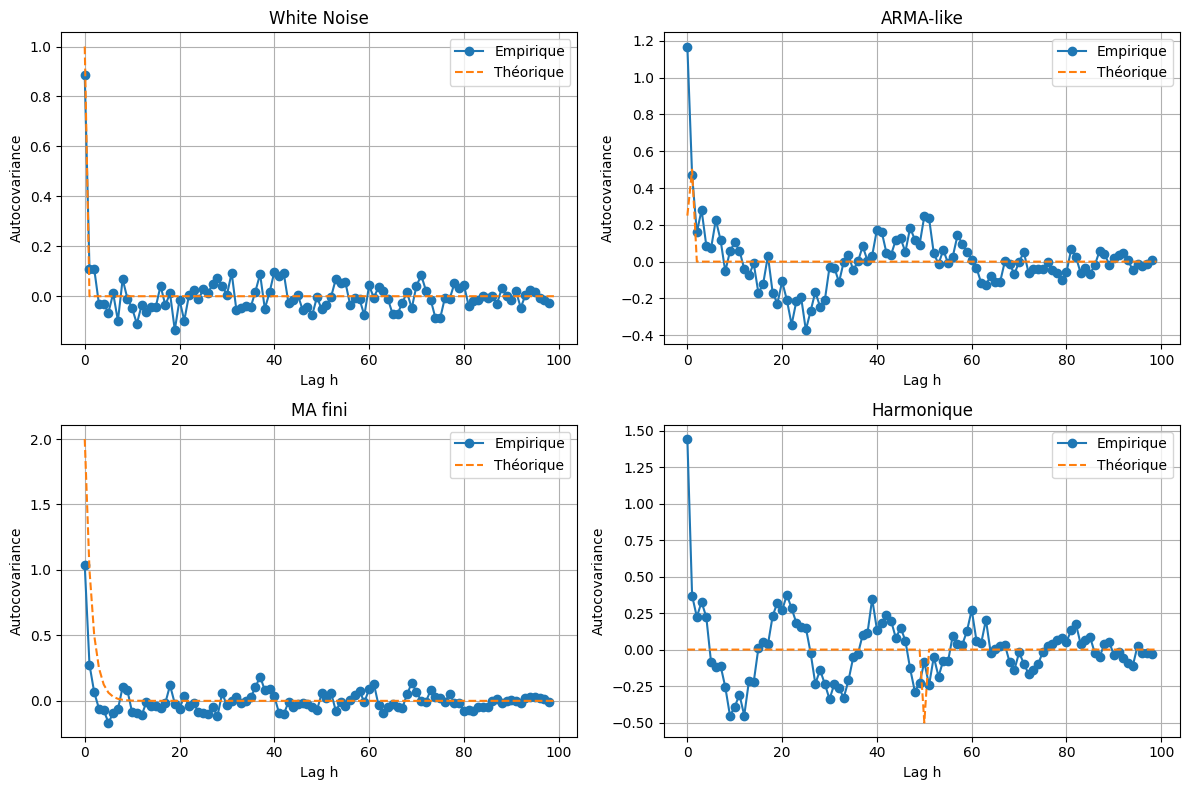

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Paramètres
# ---------------------------
T = 100
sigma = 1.0
a = 0.0
b = 0.5
K = 50
A0 = 1.0
lambda0 = np.pi / 10


# ---------------------------
# Utilities
# ---------------------------
def empirical_mean(X):
    """Return sample mean."""
    # TODO: implement empirical mean
    # hint: use numpy
    return np.mean(X)  # <-- fill


def empirical_autocov(X, h_max=None):
    """
    Empirical autocovariance for lags 0..h_max.
    ALSO: center with empirical_mean(X).
    """
    T = len(X)
    mu = empirical_mean(X)
    X= X - mu

    if h_max is None:
        h_max = T - 1
    """
    gamma = np.zeros(h_max + 1)
    # TODO: implement the loop
    for h in range(h_max + 1):
        np.mean(X[0] * X[h])
        gamma[h] = np.mean(X[0] * X[h])
    """
    X_correlation_vector = np.correlate(X, X, mode='full')
    return X_correlation_vector[T-1:T-1+h_max]/T

# ---------------------------
# 1. White Noise
# ---------------------------
# TODO: Generate Z with np.random.normal
Z = np.random .normal(0, sigma, T)
X_WN = np.zeros(T)

# TODO: fill the X_WN
X_WN = Z


# empirical
gamma_WN_emp = empirical_autocov(X_WN)

# theoretical (TODO)
gamma_WN_theo = np.zeros(T)
# TODO: fill the theoretical autocovariance for white noise
gamma_WN_theo[0]=sigma

# ---------------------------
# 2. ARMA-like : X_t = a + b Z_t + Z_{t-1}
# ---------------------------
# TODO: Generate Z with np.random.normal
Z = np.random .normal(0, sigma, T)
X_ARMA = np.zeros(T)

# TODO: fill the X_ARMA
X_ARMA[1:] = a + b*Z[1:] +Z[:-1]

gamma_ARMA_emp = empirical_autocov(X_ARMA)

gamma_ARMA_theo = np.zeros(T)
# TODO: fill the theoretical autocovariance for this MA(1):
gamma_ARMA_theo[0]= (b**2) * (sigma**2)
gamma_ARMA_theo[1]= b * (sigma**2)
# ---------------------------
# 3. MA fini
# ---------------------------
Z = np.random.normal(0, sigma, T + K)
X_MA = np.zeros(T)
coeffs = np.array([2 ** (-k) for k in range(K + 1)])

for t in range(K, T+K):
    # TODO implement the X_MA[t]
    X_MA[t-K]=np.dot(coeffs[::-1],Z[t-K:t+1 ]) +a

gamma_MA_emp = empirical_autocov(X_MA)

gamma_MA_theo = np.zeros(T)
# TODO: derive and implement gamma(h) for 0<=h<=K; else 0
for h in range(0,K+1):
      gamma_MA_theo[h] = ((2**(-h+1))-2**(-K)) * sigma**(2)
# ---------------------------
# 4. Harmonic process
# ---------------------------
Phi0 = np.random.uniform(0, 2 * np.pi)

Z = np.random.normal(0, sigma, T)
t = np.arange(T)
X_Harm = A0 * np.cos(lambda0 * t + Phi0) + Z

gamma_Harm_emp = empirical_autocov(X_Harm)

gamma_Harm_theo = np.zeros(T)
# TODO: fill theoretical gamma

gamma_Harm_theo[h]= A0/(2) * np.cos(lambda0*(h)) * sigma**(2)
# ---------------------------
# Tracé des autocovariances
# ---------------------------
processes = ["White Noise", "ARMA-like", "MA fini", "Harmonique"]
empirical = [gamma_WN_emp, gamma_ARMA_emp, gamma_MA_emp, gamma_Harm_emp]
theoretical = [gamma_WN_theo, gamma_ARMA_theo, gamma_MA_theo, gamma_Harm_theo]

plt.figure(figsize=(12, 8))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.plot(empirical[i], label="Empirique", marker="o")
    plt.plot(theoretical[i], label="Théorique", linestyle="--")
    plt.title(processes[i])
    plt.xlabel("Lag h")
    plt.ylabel("Autocovariance")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

KeyError: 10

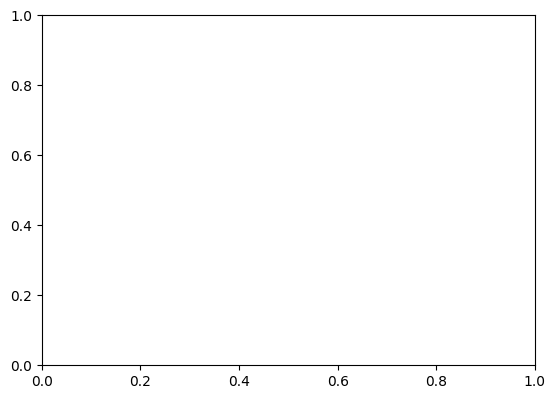

In [ ]:
# ---------------------------
# Q4. MSE et Boxplot
# ---------------------------
sigma = 1.0
a = 0.0
b = 0.5
K = 50
A0 = 1.0
lambda0 = np.pi / 10
T_list = [10, 100, 500, 1000]
n_simulations = 100


def mse_gamma(gamma_theo, gamma_emp):
    """
    Mean Squared Error between theoretical and empirical autocovariances
    Return: float (scalar MSE)
    """
    # TODO:
    mse = np.mean((gamma_theo - gamma_emp) ** 2)
    return mse
    # return mse


# implement simulation functions


def simulate_WN(T):
  return np.random.normal(0, sigma, T)
def simulate_ARMA(T):
  Z = np.random .normal(0, sigma, T)
  X_ARMA = np.zeros(T)
  X_ARMA[1:] = a + b*Z[1:] +Z[:-1]
  return X_ARMA

# TODO: fill the X_ARMA

def simulate_MA(T):
  Z = np.random.normal(0, sigma, T + K)
  X_MA = np.zeros(T)
  coeffs = np.array([2 ** (-k) for k in range(K + 1)])
  for t in range(T):
    X_MA[t]=np.dot(coeffs,Z[t:t+K+1]) +a
  return X_MA


def simulate_Harm(T):
  Phi0 = np.random.uniform(0, 2 * np.pi)

  Z = np.random.normal(0, sigma, T)
  t = np.arange(T)
  X_Harm = A0 * np.cos(lambda0 * t + Phi0) + Z

  return X_Harm


Process_names=["White Noise",'ARMA-like','MA fini','Harmonique']
MSE_results={}
for name in Process_names:
   MSE_results[name]={}


for T in [50,100,500,1000]:
    mse_white_noise=[]
    mse_arma_like=[]
    mse_ma_fini=[]
    mse_harmonique=[]
    for i in range(n_simulations):

      white_noise = simulate_WN(T)
      gamma_empirique= empirical_autocov(white_noise)
      gamma_WN_theo = np.zeros(T-1)
      gamma_WN_theo[0]=sigma
      mse_WN=np.mean((gamma_empirique-gamma_WN_theo)**2)
      mse_white_noise.append(mse_WN)


      X_ARMA = simulate_ARMA(T)
      gamma_ARMA_emp = empirical_autocov(X_ARMA)
      gamma_ARMA_theo = np.zeros(T-1)
      gamma_ARMA_theo[0]= (b**2) * (sigma**2)
      gamma_ARMA_theo[1]= b * (sigma**2)
      mse_arma= np.mean((gamma_ARMA_emp-gamma_ARMA_theo)**2)
      mse_arma_like.append(mse_arma)



      X_MA=simulate_MA(T)
      gamma_MA_emp = empirical_autocov(X_MA)
      gamma_MA_theo = np.zeros(T-1)
      if T<500:
        K=20
      for h in range(0,K+1):
           gamma_MA_theo[h] = ((2**(-h+1))-2**(-K)) * sigma**(2)
      mse_ma= np.mean((gamma_MA_emp-gamma_MA_theo)**2)
      mse_ma_fini.append(mse_arma)



      X_Harm=simulate_Harm(T)
      gamma_Harm_emp = empirical_autocov(X_Harm)
      gamma_Harm_theo = np.zeros(T-1)
      for h in range(T-1):
           gamma_Harm_theo[h]= A0/(2) * np.cos(lambda0*(h)) * sigma**(2)
      mse_harm= np.mean((gamma_MA_emp-gamma_MA_theo)**2)
      mse_harmonique.append(mse_harm)


    MSE_results["White Noise"][T]=np.array(mse_white_noise)
    MSE_results["ARMA-like"][T]=np.array( mse_arma_like)
    MSE_results["MA fini"][T]= np.array(mse_ma_fini)
    MSE_results["Harmonique"][T]=np.array(mse_harmonique)
processes=Process_names
# ---------------------------
# Build your loops as you like.
# Goal: produce a dict named MSE_results with shape:
# MSE_results = {
#     'White Noise':   {T: [mse_1, mse_2, ..., mse_n] for T in T_list},
#     'ARMA-like': {T: [ ... ]                     for T in T_list},
#     'MA fini':   {T: [ ... ]                     for T in T_list},
#     'Harmonique': {T: [ ... ]                     for T in T_list},
# }
# ---------------------------


# ---------------------------
# Boxplots des MSE (uncomment to visualize once MSE_results exists)
# ---------------------------
plt.figure(figsize=(14, 10))
for i  in range(len(processes)):
     proc_name=processes[i]
     plt.subplot(2, 2, i+1)
     data = [MSE_results[proc_name][T] for T in T_list]
     plt.boxplot(data, labels=T_list)
     plt.title(f"MSE autocovariance : {proc_name}")
     plt.xlabel("T (nombre d'échantillons)")
     plt.ylabel("MSE")
     plt.grid(True)

plt.tight_layout()
plt.show()

# Practical Session 2 — Spectral density estimation and periodogram

We aim to estimate the power spectral density (PSD) of a real, zero-mean, weakly stationary process $X_t$. We observe $X_t$ for $t \in \{0,1,\dots,n-1\}$ and will use the FFT (DFT implementation) from numpy.fft. Recall that the PSD $f_X(\lambda)$ is the DTFT ( Discrete Time Fourier Transform) of the autocovariance $\gamma(h)$:

$$f_X(\lambda)=\frac{1}{2\pi}\sum_{h\in\mathbb{Z}}\gamma(h)\,e^{-i\lambda h}.$$

For this exercise you will complete code to compute the periodogram and relate it to the empirical autocovariance.

[✍️]=write-up LaTeX or on paper, [💻]=implement with ``python``

1) [✍️] Define the sample mean $\hat\mu_n=\frac{1}{n}\sum_{t=0}^{n-1}X_t$. For $h\ge 0$, define the empirical ACF estimator
$$\hat\gamma_n(h)=
\begin{cases}
\frac{1}{n}\sum_{t=0}^{n-1-h}\big(X_t-\hat\mu_n\big)\big(X_{t+h}-\hat\mu_n\big), & h<n,\\[4pt]
0, & h\ge n,
\end{cases}$$
$\quad\quad$ and for $h<0$ set $\hat\gamma_n(h)=\hat\gamma_n(|h|)$ (real process). Define the periodogram
$$I_n(\lambda)=\frac{1}{2\pi}\sum_{h=-\,n+1}^{n-1}\hat\gamma_n(h)\,e^{-i\lambda h}.$$
$\quad\quad$ Express $I_n(\lambda)$ as a function of the DTFT of the centered data $X_t-\hat\mu_n$.
    
2) [💻] Discrete grid computation.
Deduce an algorithm to compute $I_n\!\left(\frac{2\pi k}{m}\right)$ for $k=0,\dots,m-1$, where $m\ge n$ is the DFT length. Test it on the processes from Practical Session 1.

3) [✍️💻] Recovering $\hat\gamma_n(h)$ from $I_n$.
How can you obtain $\hat\gamma_n(h)$ from the discrete set $I_n\!\left(\frac{2\pi k}{m}\right)$? Which choice of m makes the relation simple (hint: zero-padding to avoid circular wrap-around)? Verify that your implementation matches a reference autocovariance routine.

4) [💻] White-noise variance experiment.
For white noise, estimate the variance of the periodogram for several n and draw conclusions. (Expected: large variance that does not vanish with n unless you smooth/average.)  

**1**
By writing $e^{-i\lambda h} = e^{-i\lambda (h+t - t)}$ and interverting the two finite sums in  $ 2 \sum_{h=0}^{n-1}\sum_{t=0}^{n-1-h}\big(X_t-\hat\mu_n\big) e^{i\lambda  t} \big(X_{t+h}-\hat\mu_n\big)e^{-i\lambda (h+t)}$

$I_n(λ) = 1/2πn (|DTFT(X_{centered})|^2) $

**3**
We can use the inverse fourier transform formula :  
$$γ_n(h) =\frac{2π}{m}\sum_{k=-\,m+1}^{m-1}I_n(\frac{2\pi k}{m})\,e^{i 2\pi \frac{kh }{m}}.$$

m=2n-1 seems a good choice.
for m>n :  We get$ γ_n(h)= γ_n(h-n)$  for  $h>n$

In [ ]:
# Imports & helpers
# - center(x): enforce zero-mean data X_t - mu_hat
# - empirical_autocov: recall the empirical autocovariance

import numpy as np
import matplotlib.pyplot as plt

def center(x):
    x = np.asarray(x, dtype=float)
    return x - x.mean()

def empirical_autocov(x, h_max=None):
    # TODO ...
    sum =0
    x_corellate=np.correlate(x,x, mode='full')
    gamma= x_corellate[:h_max+1]/len(x)

    return gamma

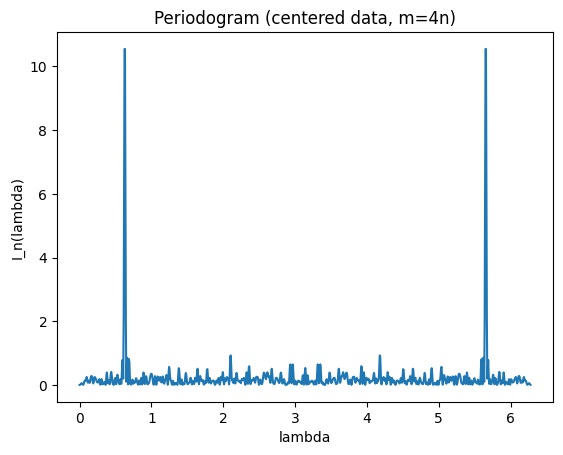

In [ ]:
# (Task 2) Periodogram on a discrete grid via FFT
# I_n(λ_k) = |DFT(X - mu_hat, m)(k)|^2 / (2π n), where λ_k = 2πk/m.
# Implement and test on data from Practical Session 1

def periodogram_fft_centered(x, m=None):
    """
    Compute periodogram on the FFT grid for centered data.
    Args:
      x: 1D array, shape (n,)
      m: FFT length (>= n). If None, uses m = n.
    Returns:
      lam: array of λ_k = 2πk/m, k=0..m-1
      I:   I_n(λ_k)
      X:   FFT values for potential reuse
    """
    x = center(np.asarray(x, dtype=float))
    n = x.size
    if m is None:
        m = n
    X = np.fft.fft(x,m)
    I = (1/(2*np.pi*n))*abs(X)**2
    lam = np.array([2*np.pi*k/m for k in range(m)])
    return lam, I, X

# ==============
# ---- Demo ----
# ================
n = 256
x = np.cos(2*np.pi*0.1*np.arange(n)) + np.random.normal(0, 1, n)

lam, I, _ = periodogram_fft_centered(x, m=4*n)
# Plot
plt.figure()
plt.plot(lam, I)
plt.xlabel("lambda")
plt.ylabel("I_n(lambda)")
plt.title("Periodogram (centered data, m=4n)")
plt.show()

# ===================================================
# TODO: Replace x with your Practical Session 1 series,
# e.g. x = your_series_array
# ===================================================

In [ ]:
# (Task 3) Recover γ̂_n(h) from I_n via IDFT of |FFT|^2
# Theory: with zero-padding m >= 2n - 1, circular correlation equals linear correlation
# Practice: implement and verify against a direct empirical ACF.

def acov_from_periodogram_via_idft(x, m=None, n_max=None):
    """
    Compute γ̂_n(h) from IDFT(|FFT|^2) with adequate zero-padding.
    Args:
      x: data (1D array)
      m: FFT length; if None, use next power of 2 >= 2n-1
    Returns:
      acov: γ̂_n (1D array)
      m:    FFT length actually used
    """
    x = center(np.asarray(x, dtype=float))
    n = x.size
    m = 2*n-1# TODO ...
    X = np.concatenate([x , np.zeros(n-1)])# TODO ...
    r_circ = 2*np.pi/m # TODO ...
    if n_max is None:
       n_max = n
    acov = 2*(np.pi/m)* np.fft.ifft(1/(2*np.pi*n)*(abs(np.fft.fft(x))**2)) # TODO ...
    return acov, m

# ---- Verification against direct computation ----
acov_fft, m_used = acov_from_periodogram_via_idft(x)
acov_emp = empirical_autocov(x, h_max=len(acov_fft)-1)
print("m used:", m_used)
print("max |diff| =", np.max(np.abs(acov_fft - acov_emp)))

m used: 511
max |diff| = 1.486729930552664


In [ ]:
# (Task 3+) Reconstruct periodogram from γ̂_n to check the Fourier pair
# I_n(λ) = (1/2π) * sum_{h=-(n-1)}^{n-1} γ̂_n(h) e^{-iλh}

def periodogram_from_acov(acov, m):
    """
    Given acov[0..n-1], build symmetric sequence and FFT to sample I_n at λ_k = 2πk/m.
    """
    n = len(acov)
    g_sym = np.concatenate([acov, acov[1:][::-1]])  # length 2n-1
    if m < len(g_sym):
        raise ValueError("m must be >= 2n-1")
    g_pad = np.zeros(m, dtype=float)
    g_pad[:len(g_sym)] = g_sym
    G = np.exp(2*np.imag(1)*np.pi*(1-m)/m)*g_pad# TODO ...
    I =(1/(2*np.pi)) * np.fft.fft(G) # TODO ...
    lam =np.array([2*np.pi*k/m  for k in range(m)]) # TODO ...
    return lam, I

# ---- Consistency check: direct periodogram vs acov->periodogram ----
m = 2048
lam1, I1, _ = periodogram_fft_centered(x, m=m)
acov, _ = acov_from_periodogram_via_idft(x, m=m, n_max=n)
lam2, I2 = periodogram_from_acov(acov, m=m)
print("grid equal:", np.allclose(lam1, lam2))
rmse = np.sqrt(np.mean((I1 - I2)**2))
print("RMSE between two routes:", rmse)

grid equal: True
RMSE between two routes: (0.813524448241487-1.6659028730315265e-20j)


C:\Users\moham\AppData\Local\Temp\ipykernel_11516\916938905.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  g_pad[:len(g_sym)] = g_sym


c:\Users\moham\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'estimated Variance for periodgram')

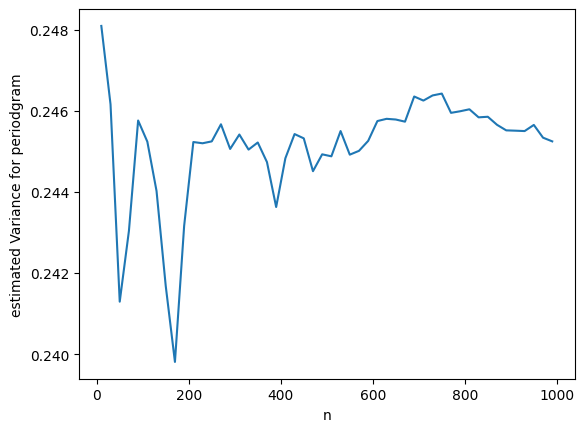

In [ ]:
T=10000
Z=simulate_WN(T)
Estimated_variances=[]
periodgramm_Z = periodogram_fft_centered(Z)
for n in  range(10,1000,20):
    periodgramm_Z = periodogram_fft_centered(Z[:n])
    variance= np.mean((periodgramm_Z-np.mean(periodgramm_Z)**2))
    Estimated_variances.append(variance)

Estimated_variances=np.array(Estimated_variances)
n_array= [10+20*i for i in range(50)]
n_array=np.array(n_array)

plt.plot(n_array,Estimated_variances)
plt.xlabel('n')
plt.ylabel('estimated Variance for periodgram')

# TSIA202a - Third Practice Session

The goal of this third partical work is to use an AR(p) process to model a speech signal, and show that this approch is surprisingly powerful despite its simplicity.

The proposed synthesis algorithm divides into several steps.
1. Filter the audio signal to emphasize the highest frequencies (in order to flatten the spectrum and reduce precision issues with FFT computations).
2. Split the signal into several overlapping frames and iterate over them.
    1. Detect if the frame corresponds to noise or to a voiced signal, and estimate the fundamental frequency in the later case.
    2. Estimate the AR(p) coefficients using Yule-Walker equations.
    3. Re-synthetise the frame using the AR(p) coefficients, starting from a white noise in the case of a noisy frame, or a Dirac comb in the case of a voiced frame.
3. Overlap-add the synthesized frames with a Hanning window.
4. Filter the synthesised signal to de-emphasize the highest frequencies.

We propose to implement this algorithm in two parts. First, we will derive the Yule-Walker equations, and test them on synthetic data. Then, we will code the synthesis algorithm and apply it on a real world speech signal.


# 1. Yule-Walker equations

Let us consider a causal, zero-mean, AR(p) process defined by the following recurrent equation:
$$
X_t = \phi_1 X_{t-1} + \phi_2 X_{t-2} + \ldots + \phi_p X_{t-p}+Z_t
$$
where $\{Z_t , t \in \mathbb{Z}\}$ is a weak white noise with variance $\sigma^2$.

1. Show that, $\forall h \geq 1, \mathbb{E}[X_{t-h}Z_t]=0$.
2. Deduce a recurrent relation between $\gamma(h)$ and $\gamma(h-1),\gamma(h-2),\ldots,\gamma(h-p)$, for $h \geq 1$.
3. We consider separately the case $h=0$: find a new relationship between $\gamma(0)$ and $\gamma(-1),\gamma(-2),\ldots,\gamma(-p)$.
4. Put these relationships in matrix form:
\begin{equation}
\Gamma_{p+1}[1 \; -\phi_1 \; \ldots \; -\phi_p]^T = [\sigma^2 \; 0 \; \ldots \; 0]^T
\end{equation}
where $\Gamma_{p+1}$ is a suitable Toeplitz matrix that you have to determine.

# 2. Evaluation on synthetic data

We will now evaluate equation $(1)$ on a synthetically generated AR(p) process.

1. Generate n=1000 samples of an AR(4) process.
2. Estimate $\Gamma_{p+1}$ using these samples.
3. Use equation $(1)$ to estimate $\sigma^2$ and the coefficients $\phi_1,\phi_2,\ldots,\phi_p$. Compute the relative error between the estimated and the true coefficients.
4. Estimate power spectral distribution of the synthesized signal. Compare with the theoretical distribution obtained from the poles of $1/\Phi(z^{-1})$.

# 3. Speech modeling

We will now implement the synthesis algorithm and evaluate it on a speech signal.

A code template is provided below. We will use the file audio.wav to test the algorithm.


LIsten to the original and synthesized signal by using any audio player. Try to modify the pitch of the synthesised signal and listen to the result.


**1.Yule-Walker Equations**
**1** Let's start by showing $X_t \in Span(ϵ_{t-h})_{h \in ℕ }$

This is True for $t=0$: $X_0 =ϵ_0$
Supposing this propertie holds for all $t<s$ , Remarquing that $X_s \in Span(X_{t-1} , X_{t-2} ,... X_{t-p} , ϵ_t)$ , We conclude that this propertie holds for all $s \in ℕ$.

Eventually , we can use that $E(ϵ_{t-s} ϵ_t )=0$ for all $s>0$  to conclude that : $\forall h \geq 1, \mathbb{E}[X_{t-h}Z_t]=0$.


**2**
$
\Gamma (h) = \phi_1 \Gamma (h-1) + \phi_2 \Gamma (h-2) + \ldots + \phi_p \Gamma (h-p)
$

**3**
Remarking that (using linearity of expectation) : $$
E(X_t ϵ_t)= \phi_1 E(X_{t-1} ϵ_t) + \phi_2 E(X_{t-2} ϵ_t) + \ldots + \phi_p E(X_{t-p} \epsilon_t) + σ^2 =σ^2
$$
We conclude that
$E(X_t X_t) = γ(0)= \phi_1 E(X_{t-1} X_t) + \phi_2 E(X_{t-2} X_t) + \ldots + \phi_p E(X_{t-p} X_t) + σ^2= \phi_1 γ(-1) + \phi_2 \gamma( -2)  + \ldots + \phi_p γ(-p) + σ^2$


**4**
We denote by $Γ_{p+1}= (γ(i-j)_{(0≲i,j≲p)})$
The 2 equations above can be reexpressed as :
\begin{equation}
\Gamma_{p+1}[1 \; -\phi_1 \; \ldots \; -\phi_p]^T = [\sigma^2 \; 0 \; \ldots \; 0]^T
\end{equation}

In [ ]:
## imports
!pip install librosa
!pip install tqdm
import librosa
import soundfile as sf
import scipy
import numpy as np
import math
from collections import defaultdict
from tqdm import tqdm
import matplotlib.animation
import matplotlib.pyplot as plt
from IPython.display import HTML

### 1. Yule-Walker equations

In [ ]:
T = 22000
p = 4
# AR(4)
size=T
phi_true = np.array([0.75, -0.1, 0.08, -0.05], dtype=float)
sigma2_true = 1.0

# AR(p) ：X_t = \sum phi_k X_{t-k} + Z_t
X = np.zeros(T + 5 * p, dtype=float)
Z = np.random.normal(0.0, np.sqrt(sigma2_true), size=T + 5 * p)
for t in range(p, T + 5 * p):
    X[t] = np.dot(phi_true, X[t - p : t][::-1]) + Z[t]
X = X[5 * p :]
X = X - X.mean()

# (1) check E[X_{t-h} Z_t] ≈ 0, h>=1（Approximate using sample covariance）
Hmax = 8
Z_5p=Z[5*p:]
cov_xz = []
# TODO ...
for h in range(1, Hmax + 1):
    corr_X_Z = np.correlate(Z_5p, X, mode='full')
    cov_xz.append(corr_X_Z[h] / len(X))
print("[P1-1] sample E[X_{t-h} Z_t] (h=1..8):", np.round(cov_xz, 4))

# (2) Verify recursion using sample autocovariance: γ(h) ≈ sum_{k=1}^p φ_k γ(h-k)
corr_full = np.correlate(X, X, mode="full")
gamma_hat = corr_full[len(X) - 1 : len(X) - 1 + (Hmax + p + 1)] / len(X)  # γ(0..Hmax+p)
chk = []
for h in range(1,Hmax + 1):
    chk.append(gamma_hat[h]-np.sum(phi_true * gamma_hat[h+1:h+p+1]))

print("[P1-2] γ(h) - sum φ_k γ(h-k) (h=1..8):", np.round(chk, 6))

# (3) h=0 case：γ(0) ≈ sum φ_k γ(k) + σ^2
lhs = gamma_hat[0]
rhs = sigma2_true + np.sum(phi_true * gamma_hat[1:p+1])
print(
    "[P1-3] γ(0) vs sum φ_k γ(k) + σ^2:",
    float(lhs),
    float(rhs),
    "diff=",
    float(lhs - rhs),
)

# (4) Γ_{p+1} [1, -φ]^T = [σ^2, 0,...,0]^T
Gamma_p1 = scipy.linalg.toeplitz(gamma_hat[: p + 1])  # Toeplitz(γ(0..p))
c_vec = np.zeros(p + 1)
c_vec[0] = 1.0
c_vec[1:] = -phi_true
prod = Gamma_p1 @ c_vec.transpose()
target = np.array([sigma2_true] + [0] * p).transpose()
print("[P1-4] ||Γ_{p+1} c - target|| =", float(scipy.linalg.norm(prod - target)))

[P1-1] sample E[X_{t-h} Z_t] (h=1..8): [ 0.0002  0.0001 -0.      0.0001  0.0004  0.0002 -0.0002 -0.0005]
[P1-2] γ(h) - sum φ_k γ(h-k) (h=1..8): [0.739113 0.451984 0.348726 0.235962 0.147068 0.090373 0.072243 0.041954]
[P1-3] γ(0) vs sum φ_k γ(k) + σ^2: 1.9725237253278385 1.972817484177482 diff= -0.000293758849643444
[P1-4] ||Γ_{p+1} c - target|| = 0.029385224140571035


### 2. Evaluation on synthetic data

[ 0.00016923  0.00011708 -0.00014938 -0.00037815 -0.00046611]
[P2] φ_true=[ 0.75 -0.1   0.08 -0.05], φ_est=[ 1.561  -0.0954  0.3438  0.4119], rel.err=127.20%,  σ²_est≈0.0009


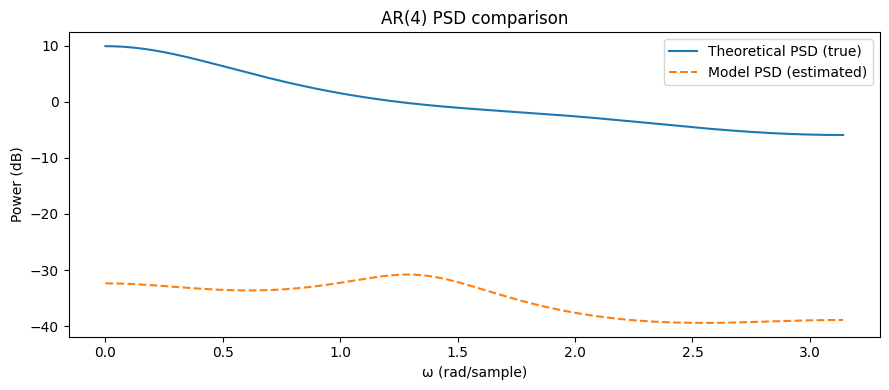

In [ ]:
np.random.seed(1)
n = 1000
# Generate AR(4) samples
Xn = np.zeros(n + 5*p)
Zn = np.random.normal(0.0, np.sqrt(sigma2_true), size=n + 5*p)
for t in range(p, n + 5*p):
    Xn[t] = np.dot(phi_true, Xn[t-p:t][::-1]) + Zn[t]
Xn = Xn[5*p:]
Xn = Xn - Xn.mean()

# estimate Γ_{p+1}
corr_full_n = np.correlate(Xn, Xn, mode='full')
gamma_b = corr_full_n[ (p + 1):] / np.array([len(X)-i for i in range(p+1)])# TODO: Estimate the autocovariance vector [gamma(0), gamma(1), ..., gamma(p)].
print(gamma_b)
Gamma_hat = scipy.linalg.circulant(gamma_b)# TODO: Construct the (p+1)x(p+1) Toeplitz autocovariance matrix 'Gamma_hat' from 'gamma_b'.
            # (Hint: use scipy.linalg.toeplitz())

v = np.zeros(p+1); v[0] = 1.0

'''
Given Γ_{p+1} c = [σ^2,0,...,0]^T，solve c=Γ^{-1} v.
Since σ^2=1/c0，coef = c*σ^2
'''
c = scipy.linalg.solve(Gamma_hat ,v)# TODO: Solve the linear system 'Gamma_hat * c = v' for the vector 'c'.
    # (Hint: use scipy.linalg.solve())

sigma2_est = 1.0 / c[0]
coef = c * sigma2_est
coef[0] = 1.0
phi_est = -coef[1:]# TODO: Extract the estimated AR coefficients 'phi_est' from the 'coef' vector.
          # Remember coef = [1, -phi_1, -phi_2, ..., -phi_p]. You need to isolate and negate the phi elements.

rel_err = scipy.linalg.norm(phi_est - phi_true) / scipy.linalg.norm(phi_true)
print(f"[P2] φ_true={phi_true}, φ_est={np.round(phi_est,4)}, rel.err={rel_err:.2%},  σ²_est≈{sigma2_est:.4f}")

# PSD compare（Theo vs Samples)
# Theo：S(ω) = σ² / |1 - sum φ_k e^{-i ω k}|²
w = np.linspace(0, np.pi, 1024)
w1, H_true = scipy.signal.freqz([1.0], np.r_[1.0, -phi_true], worN=w)
S_theo = sigma2_true*abs(H_true)**2# TODO: the theoretical PSD
w2, H_est = scipy.signal.freqz([1.0], coef, worN=w)
S_est_model = sigma2_est*(abs(H_est)**2)# TODO: Calculate the model-based PSD

win = np.hanning(n)
Xw = Xn * win
Dw = np.fft.rfft(Xw, n=2*n)
S_emp = (np.abs(Dw)**2) / (len(Xw))  # periodogram

plt.figure(figsize=(9,4))
plt.plot(w, 10*np.log10(S_theo+1e-12), label="Theoretical PSD (true)")
plt.plot(w, 10*np.log10(S_est_model+1e-12), '--', label="Model PSD (estimated)")
plt.xlabel("ω (rad/sample)"); plt.ylabel("Power (dB)"); plt.title("AR(4) PSD comparison")
plt.legend(); plt.tight_layout(); plt.show()

### 3. Speech modeling

In [ ]:
"""
The hyperparameters
"""
sampling_rate = 8000  # (Hz)
frame_duration = 0.04  # duration of the analysis frames (seconds)
overlap_ratio = 0.5  # overlap ratio between two consecutive analysis frames
p = 12  # AR(p) model order
f_min = 80  # minimum frequency for pitch detection (Hz)
f_max = 400  # maximum frequency for pitch detection Hz)
pitch_detection_threshold = 0.5  # threshold for pitch detection

In [ ]:
## synthesis
# load audio
x = librosa.load("audio.wav", sr=sampling_rate)[0]

# pre-emphasis filtering
x = scipy.signal.lfilter(x,[1],[1,-0.98])  # TODO: Apply the pre-emphasis filter H(z) = 1 - 0.98*z^-1.
# Use scipy.signal.lfilter. The 'a' coefficients are [1] and 'b' are [1, -0.98].

# handy variables
n_frame = (
    math.floor(len(x) / (sampling_rate * frame_duration * (1 - overlap_ratio))) - 1
)  # discard last frame
frame_length = int(sampling_rate * frame_duration)
min_period = math.floor(sampling_rate / f_max)
max_period = math.ceil(sampling_rate / f_min)
synthesis = np.zeros(len(x))
log_dict = defaultdict(list)

# loop over frames
for frame_index in tqdm(range(n_frame)):
    # extract frame
    start = int(frame_index * sampling_rate * frame_duration * (1 - overlap_ratio))
    end = int(start + frame_length)  # TODO: Calculate the 'end' index of the frame based on 'start' and 'frame_length'.
    frame = x[start:end]  # TODO: Extract the 'frame' from the audio signal 'x' using 'start' and 'end' indices.

    # detect pitch
    auto_covariance = np.fft.irfft(
        np.abs(np.fft.rfft(frame - np.mean(frame), (2 * frame_length - 1))) ** 2
        / frame_length
    )[:frame_length]
    min_period = math.floor(sampling_rate / f_max)
    max_period = math.ceil(sampling_rate / f_min)
    arg_max = np.argmax(auto_covariance[min_period:]) + min_period
    pitch = sampling_rate / arg_max
    max_value = auto_covariance[min_period:].max() / auto_covariance[0]
      # TODO: Find the pitch period.
    # 1. Find the index (argmax) of the peak in auto_covariance[min_period:].
    # 2. Add 'min_period' to this index to get the 'pitch' period.
    # 3. Calculate the normalized 'max_value' (auto_covariance[min_period:].max() / auto_covariance[0]).
    arg_max = np.argmax(auto_covariance[min_period:]) + min_period
    pitch = sampling_rate / arg_max
    max_value = auto_covariance[min_period:].max() / auto_covariance[0]

    if max_period<pitch or max_value<pitch_detection_treshhold :  # TODO: Write the condition to detect a silent/unvoiced frame.
        # Check if 'pitch' is greater than 'max_period' OR
        # if the normalized 'max_value' (with correction) is less than 'pitch_detection_threshold'.
        pitch = 0

    # estimate AR(p) coefficients
    gamma = scipy.linalg.toeplitz(auto_covariance)  # TODO: Build the (p+1)x(p+1) Toeplitz auto-covariance matrix using scipy.linalg.toeplitz.
    # The input should be the first (p+1) values of 'auto_covariance'.
    v = np.array([1 if k == 0 else 0 for k in range(p + 1)])
    coefficient = np.linalg(gamma,v)  # TODO: Solve the Yule-Walker equations (gamma * coefficient = v) for 'coefficient' using np.linalg.solve.
    sigma = 1/coefficient[0]  # TODO: Calculate the gain squared (variance), 'sigma', which is 1.0 / coefficient[0].
    coefficient = coefficient * sigma

    # re-synthetise frame
    if pitch == 0:
        noise = np.random.normal(0.0, 1.0, frame_length + p)
        frame_r = scipy.signal.lfilter([1], coefficient, noise)
    else:
        dirac_comb = np.zeros(frame_length + p)
        dirac_comb[p::pitch] = 1.0
        frame_r = scipy.signal.lfilter([1], coefficient, dirac_comb)
    frame_r = frame_r[p:]
    normalization_factor = np.sqrt(sigma / np.var(frame_r))
    frame_r = normalization_factor * frame_r[:frame_length]

    # overlap-add
    frame_r*= np.hanning(frame_length)
    synthesis[start:end]= frame_r # TODO: Apply the Overlap-Add method.
    # 1. Multiply the synthesized 'frame_r' by a Hanning window (np.hanning(frame_length)).
    # 2. Add the result to the main 'synthesis' buffer at the 'start:end' position.

    # compute power spectral density (for logging purposes)
    original_psd = (
        np.abs(np.fft.rfft(frame * np.hanning(frame_length))) ** 2
    ) / frame_length
    synthesis_psd = (
        np.abs(np.fft.rfft(frame_r * np.hanning(frame_length))) ** 2
    ) / frame_length

    # log
    log_dict["frame"].append(frame)
    log_dict["pitch"].append(pitch)
    log_dict["sigma"].append(sigma)
    log_dict["coefficient"].append(coefficient)
    log_dict["frame_r"].append(frame_r)
    log_dict["original_psd"].append(original_psd)
    log_dict["synthesis_psd"].append(synthesis_psd)

# de-emphasis filtering
synthesis = scipy.signal.lfilter([1],[1,-0.98]) # TODO: Apply the de-emphasis filter, which is the inverse of the pre-emphasis filter.
# Use scipy.signal.lfilter. The 'b' coefficients are [1] and 'a' are [1, -0.98].

# log
sf.write("synthesis.wav", synthesis, sampling_rate)
log_dict["synthesis"].append(synthesis)
log_dict = {k: np.array(v) for k, v in log_dict.items()}

In [ ]:
## plot
# time axis for plotting
sample_time = np.linspace(0, len(x) / sampling_rate, len(x))
frame_time = np.linspace(0, n_frame * frame_duration * (1 - overlap_ratio), n_frame)

# waveform
plt.figure(figsize=(8, 2))
plt.title("waveform")
plt.plot(sample_time, x)
plt.show()

# pitch
plt.figure(figsize=(8, 2))
plt.title("pitch")
plt.plot(frame_time, log_dict["pitch"])
plt.show()

# variance
plt.figure(figsize=(8, 2))
plt.title("sigma")
plt.plot(frame_time, log_dict["sigma"])
plt.show()

# power spectral density
fig, ax = plt.subplots()
fig.suptitle("estimated & theoretical spectral density")
y_min = min(log_dict["original_psd"].min(), log_dict["synthesis_psd"].min())
y_max = max(log_dict["original_psd"].max(), log_dict["synthesis_psd"].max())


def animate(i):
    ax.cla()
    ax.set_ylim([y_min - 0.1, y_max + 0.1])
    ax.plot(log_dict["original_psd"][i], label="original_psd")
    ax.plot(log_dict["synthesis_psd"][i], label="synthesis_psd")


animation = matplotlib.animation.FuncAnimation(
    fig, animate, frames=len(log_dict["original_psd"])
)
display(HTML(animation.to_jshtml()))
plt.close()